## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import time

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
pos_train_df = pd.read_csv('/content/train_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
neg_train_df = pd.read_csv('/content/train_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)
pos_test_df = pd.read_csv('/content/test_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
neg_test_df = pd.read_csv('/content/test_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)

In [4]:
train_df = pd.concat([pos_train_df, neg_train_df], axis=0).sample(frac=1, random_state=42)
train_df.columns = ['sentiment', 'text']
test_df = pd.concat([pos_test_df, neg_test_df], axis=0).sample(frac=1, random_state=42)
test_df.columns = ['sentiment', 'text']

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (45275, 2)
Test shape: (11520, 2)


## 2. Data Exploration

In [5]:
train_df.head()

,sentiment,text
21985,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊
7725,pos,تيشرت القائد 💙
9147,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...
14470,neg,المونافري طلع برهوش .. سدينا 😤
4329,neg,منو خر بيتهم مثلنا 😩


In [6]:
test_df.head()

,sentiment,text
1078,pos,#مسابقة والجائزة 💰 / من أول من فتق لسانه بالعر...
3563,neg,❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه و...
3299,pos,"✨ لاتحزن ودع القلق,يستجيب لك الكريم هو يأخرها ..."
2142,neg,بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...
5285,neg,تلاتين سنة بترقص .. الليلة رقصتنا أنا ببكي 😭 د...


In [7]:
print(f"Missing values - Train: {train_df.isna().sum().sum()}, Test: {test_df.isna().sum().sum()}")
print(f"Duplicates - Train: {train_df.duplicated().sum()}, Test: {test_df.duplicated().sum()}")

Missing values - Train: 0, Test: 0
Duplicates - Train: 15721, Test: 2679


In [8]:
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

print(f"After removing duplicates - Train: {train_df.shape}, Test: {test_df.shape}")

After removing duplicates - Train: (29554, 2), Test: (8841, 2)


In [9]:
print(f"Train sentiment distribution:")
print(train_df['sentiment'].value_counts(normalize=True) * 100)
print(f"\nTest sentiment distribution:")
print(test_df['sentiment'].value_counts(normalize=True) * 100)

Train sentiment distribution:
sentiment
neg    51.075996
pos    48.924004
Name: proportion, dtype: float64

Test sentiment distribution:
sentiment
neg    50.390227
pos    49.609773
Name: proportion, dtype: float64


## 3. Text Preprocessing

In [10]:
print(train_df['text'].iloc[0])

مقال يدور حول الحمى يوشك ان يقع فيه 😊


### 3.1 Remove Emojis

In [11]:
def remove_emojis(text):
    pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
                           "]+", flags=re.UNICODE)
    return pattern.sub(r' ', text)

train_df['text'] = train_df['text'].apply(lambda x: remove_emojis(x))
test_df['text'] = test_df['text'].apply(lambda x: remove_emojis(x))

### 3.2 Remove Punctuation

In [12]:
punct = string.punctuation
def remove_punct(text):
    return ''.join(x for x in text if x not in punct)

train_df['text'] = train_df['text'].apply(lambda x: remove_punct(x))
test_df['text'] = test_df['text'].apply(lambda x: remove_punct(x))

### 3.3 Remove Stopwords

In [13]:
def remove_stopwords(text):
    stop_words = set(stopwords.words('arabic'))
    words = text.split()
    return ' '.join([x for x in words if x not in stop_words]).strip()

train_df['text'] = train_df['text'].apply(lambda x: remove_stopwords(x))
test_df['text'] = test_df['text'].apply(lambda x: remove_stopwords(x))

In [14]:
print(train_df['text'].iloc[0])

مقال يدور حول الحمى يوشك ان يقع


## 4. Encode Target

In [15]:
mapping = {'neg': 0, 'pos': 1}
train_df['sentiment'] = train_df['sentiment'].map(mapping)
test_df['sentiment'] = test_df['sentiment'].map(mapping)


X_train = train_df['text']
y_train = train_df['sentiment']
X_test = test_df['text']
y_test = test_df['sentiment']

## 5. TF-IDF Vectorization

In [16]:
vectorizer = TfidfVectorizer(min_df=0.0001, max_df=0.95)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

## 6. Model Training and Evaluation

In [17]:
results = []

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
    print(f"Training {model_name}...")
    start_time = time.time()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    training_time = time.time() - start_time

    print(f"✓ {model_name} completed in {training_time:.2f} seconds")
    print(f"  Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}\n")

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time (s)': training_time
    }

In [18]:
# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
results.append(train_and_evaluate(lr_model, 'Logistic Regression', X_train, y_train, X_test, y_test))

Training Logistic Regression...
✓ Logistic Regression completed in 1.13 seconds
  Accuracy: 0.7026, F1-Score: 0.6873



In [19]:
# 2. Naive Bayes
nb_model = MultinomialNB()
results.append(train_and_evaluate(nb_model, 'Naive Bayes', X_train, y_train, X_test, y_test))

Training Naive Bayes...
✓ Naive Bayes completed in 0.06 seconds
  Accuracy: 0.7103, F1-Score: 0.6924



In [20]:
# 3. Support Vector Machine
svm_model = SVC(kernel='linear', probability=True, random_state=42)
results.append(train_and_evaluate(svm_model, 'SVM (Linear)', X_train, y_train, X_test, y_test))

Training SVM (Linear)...
✓ SVM (Linear) completed in 494.36 seconds
  Accuracy: 0.7044, F1-Score: 0.6903



In [21]:
# 4. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
results.append(train_and_evaluate(dt_model, 'Decision Tree', X_train, y_train, X_test, y_test))

Training Decision Tree...
✓ Decision Tree completed in 30.35 seconds
  Accuracy: 0.7118, F1-Score: 0.6980



In [22]:
# 5. Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
results.append(train_and_evaluate(rf_model, 'Random Forest', X_train, y_train, X_test, y_test))

Training Random Forest...
✓ Random Forest completed in 384.44 seconds
  Accuracy: 0.7398, F1-Score: 0.7211



In [23]:
# 6. Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=300, random_state=42)
results.append(train_and_evaluate(gb_model, 'Gradient Boosting', X_train, y_train, X_test, y_test))

Training Gradient Boosting...
✓ Gradient Boosting completed in 31.49 seconds
  Accuracy: 0.6485, F1-Score: 0.5609



In [24]:
# 7. AdaBoost
ada_model = AdaBoostClassifier(n_estimators=300, random_state=42)
results.append(train_and_evaluate(ada_model, 'AdaBoost', X_train, y_train, X_test, y_test))

Training AdaBoost...
✓ AdaBoost completed in 12.93 seconds
  Accuracy: 0.5882, F1-Score: 0.4113



In [25]:
# 8. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
results.append(train_and_evaluate(knn_model, 'K-Nearest Neighbors', X_train, y_train, X_test, y_test))

Training K-Nearest Neighbors...
✓ K-Nearest Neighbors completed in 18.57 seconds
  Accuracy: 0.6023, F1-Score: 0.5441



In [26]:
# 9. LightGBM
lgbm_model = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1, n_jobs=-1)
results.append(train_and_evaluate(lgbm_model, 'LightGBM', X_train, y_train, X_test, y_test))

Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✓ LightGBM completed in 6.36 seconds
  Accuracy: 0.6660, F1-Score: 0.6308



In [27]:
# 10. XGBoost
xgb_model = XGBClassifier(n_estimators=300, random_state=42, eval_metric='logloss', n_jobs=-1)
results.append(train_and_evaluate(xgb_model, 'XGBoost', X_train, y_train, X_test, y_test))

Training XGBoost...
✓ XGBoost completed in 23.89 seconds
  Accuracy: 0.6819, F1-Score: 0.6358



## 7. Results Analysis and Comparison

In [28]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Random Forest,0.739848,0.770207,0.677839,0.721077,0.818153,384.435385
1,Decision Tree,0.711797,0.726914,0.671227,0.697961,0.723349,30.350939
2,Naive Bayes,0.710327,0.731540,0.657319,0.692446,0.776356,0.058459
3,SVM (Linear),0.704445,0.718835,0.663931,0.690293,0.767346,494.355693
4,Logistic Regression,0.702635,0.718478,0.658687,0.687284,0.767412,1.126387
5,XGBoost,0.681936,0.736053,0.559508,0.635751,0.741678,23.892902
6,LightGBM,0.665988,0.698312,0.575239,0.630829,0.728747,6.355376
7,Gradient Boosting,0.648456,0.737370,0.452576,0.560893,0.705498,31.488464
8,K-Nearest Neighbors,0.602307,0.630788,0.478340,0.544087,0.642378,18.573011
9,AdaBoost,0.588169,0.707059,0.290014,0.411318,0.613733,12.933381


In [29]:
results_df.to_csv('model_comparison_results.csv', index=False)

In [30]:
best_model = results_df.iloc[0]
print(f"\n Best Model: {best_model['Model']}")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   ROC-AUC: {best_model['ROC-AUC']:.4f}")


 Best Model: Random Forest
   F1-Score: 0.7211
   Accuracy: 0.7398
   ROC-AUC: 0.8182


## 8. Visualization

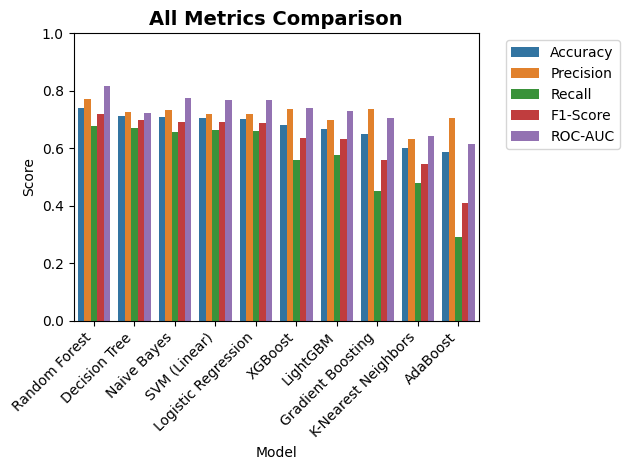

In [31]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_melted = results_df.melt(id_vars='Model', value_vars=metrics_to_plot,
                                  var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=45, ha='right')
plt.title('All Metrics Comparison', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5757/3767515014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='F1-Score', palette=colors)


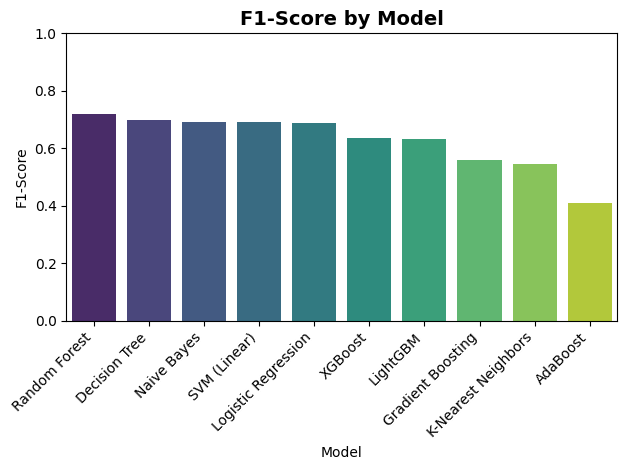

In [32]:
colors = sns.color_palette('viridis', len(results_df))
sns.barplot(data=results_df, x='Model', y='F1-Score', palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('F1-Score by Model', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

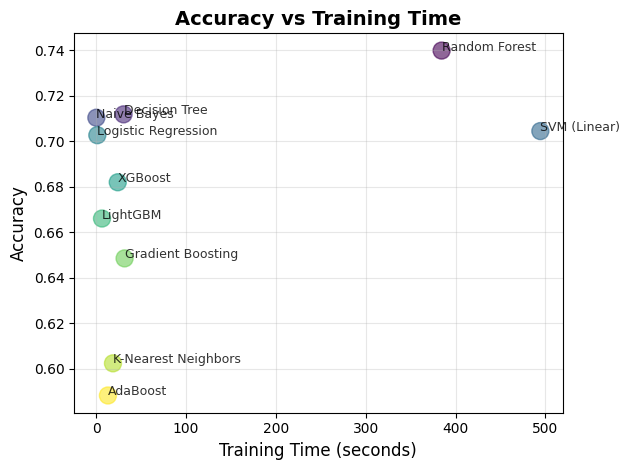

In [33]:
plt.scatter(results_df['Training Time (s)'], results_df['Accuracy'], s=150, alpha=0.6, c=range(len(results_df)), cmap='viridis')
for i, model in enumerate(results_df['Model']):
    plt.annotate(model, (results_df['Training Time (s)'].iloc[i],
                         results_df['Accuracy'].iloc[i]),
                fontsize=9, alpha=0.8)
plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Training Time', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5757/2747913068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='ROC-AUC', palette=colors)


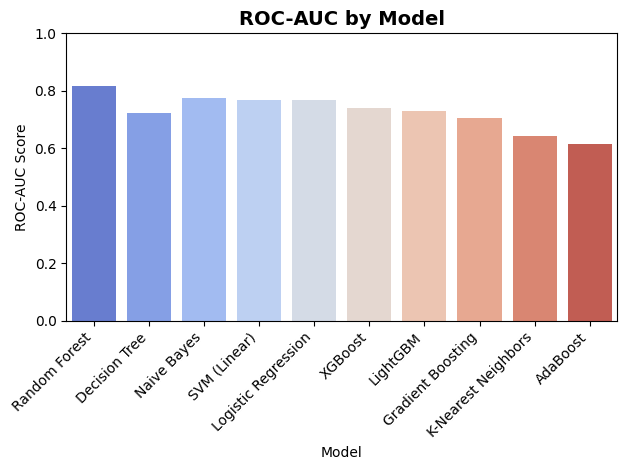

In [34]:
colors = sns.color_palette('coolwarm', len(results_df))
sns.barplot(data=results_df, x='Model', y='ROC-AUC', palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('ROC-AUC by Model', fontsize=14, fontweight='bold')
plt.ylabel('ROC-AUC Score')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()